# Telco Customer Churn — Exploratory Data Analysis (Outline Only)

**Author:** Allison Schiltz

> Dataset reference: *Telco Customer Churn* (Kaggle).
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code


**Inputs expected**
- Cleaned dataset from `data/processed/`
- Column-role manifest from data-wrangling handoff (ID, target, numeric, categorical, booleans)

**Primary goals**
- Understand target distribution and key drivers
- Identify relationships, interactions, and potential leakage
- Inform feature engineering and modeling choices


## 0. Environment & Imports (no code provided here)

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
import math

# Data profiling (optional - for quick reports)
from ydata_profiling import ProfileReport

# Warning management
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display options for better output
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
plt.style.use('default')
%matplotlib inline

print("Environment | pandas", pd.__version__, "| numpy", np.__version__)

Environment | pandas 2.3.0 | numpy 2.1.3


## 1. Load Clean Data & Manifests
- Load processed dataset from `data/processed/`
- Load column-role manifest
- Basic integrity checks (shape, dtypes, head/tail)


In [11]:
# Load cleaned dataset
telco_clean = pd.read_csv('../data/processed/telco_wrangling_cleaned.csv')

# Load column-role manifest  
column_roles = pd.read_csv('../references/telco_column_role_manifest_template.csv')

# Basic integrity checks
print("Shape:", telco_clean.shape)
print("Info:")
telco_clean.info()
print("\nHead:")
print(telco_clean.head())
print("\nColumn roles:")
print(column_roles)

Shape: (7032, 26)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       7032 non-null   object 
 1   gender                           7032 non-null   object 
 2   SeniorCitizen                    7032 non-null   object 
 3   Partner                          7032 non-null   object 
 4   Dependents                       7032 non-null   object 
 5   tenure                           7032 non-null   int64  
 6   PhoneService                     7032 non-null   object 
 7   MultipleLines                    7032 non-null   object 
 8   InternetService                  7032 non-null   object 
 9   OnlineSecurity                   7032 non-null   object 
 10  OnlineBackup                     7032 non-null   object 
 11  DeviceProtection                 7032 non-null   object 
 

In [105]:
# Convert categorical, boolean, and target columns to proper dtypes
categorical_columns = column_roles[column_roles['role'].isin(['categorical', 'boolean', 'target'])]['column_name']

for col in categorical_columns:
    telco_clean[col] = telco_clean[col].astype('category')

# Convert engineered boolean to categorical for consistency

telco_clean['short_tenure_month_to_month_eng'] = telco_clean['short_tenure_month_to_month_eng'].map({True: 'Yes', False: 'No'}).astype('category')

print("\nUpdated data types:")
# Sort by data type name (convert to string first to avoid comparison issues)
print(telco_clean.dtypes.astype(str).sort_values())



Updated data types:
TechSupport                        category
Churn                              category
PaymentMethod                      category
PaperlessBilling                   category
Contract                           category
StreamingMovies                    category
StreamingTV                        category
DeviceProtection                   category
OnlineBackup                       category
short_tenure_month_to_month_eng    category
InternetService                    category
MultipleLines                      category
PhoneService                       category
Dependents                         category
Partner                            category
SeniorCitizen                      category
gender                             category
OnlineSecurity                     category
MonthlyCharges                      float64
TotalCharges                        float64
tenure                                int64
total_services_eng                    int64
is_month_to

## 2. Target Variable Audit (`Churn`)
- Class balance (counts, percentages)


Churn counts: Churn
No     5163
Yes    1869
Name: count, dtype: int64 

Churn proportion: Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64 

Churn missing values: 0


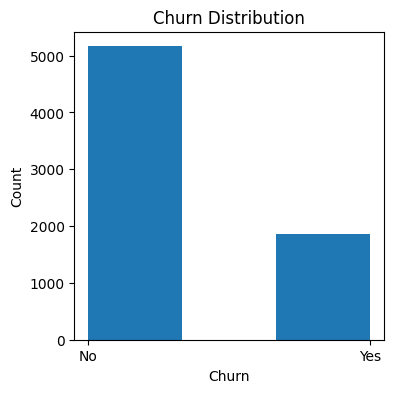

In [38]:
churn_counts = telco_clean['Churn'].value_counts()
print("Churn counts:", churn_counts, "\n")

churn_proportion = telco_clean['Churn'].value_counts(normalize=True)
print("Churn proportion:", churn_proportion, "\n")

print("Churn missing values:", telco_clean['Churn'].isnull().sum())

plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


## 3. Univariate Exploration
### 3.1 Numeric
- Distribution plots, summary stats, skewness/kurtosis

In [ ]:
# Identify numeric columns
count_roles = column_roles['role'].value_counts()
print(count_roles, '\n')
numeric_cols = column_roles[column_roles['role'] == 'numeric']['column_name']
print(numeric_cols)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group_eng', 'total_services_eng',
       'monthly_charges_bin_eng', 'is_month_to_month_eng', 'short_tenure_month_to_month_eng'],
      dtype='object')
role
categorical    14
numeric         3
boolean         2
id              1
target          1
Name: count, dtype: int64 

2            tenure
3    MonthlyCharges
4      TotalCharges
Name: column_name, dtype: object


In [88]:
# print column names for reference
print('column names:', column_roles.columns.tolist(), '\n')

# Identify categorical and boolean columns
categorical_cols = column_roles[column_roles['role'] == 'categorical']['column_name']
boolean_cols = column_roles[column_roles['role'] == 'boolean']['column_name']

print('Categorical columns:\n', categorical_cols.tolist(), '\n')
print('Boolean columns:\n', boolean_cols.tolist(), '\n')

# Frequency check for non-numeric columns
all_non_numeric = pd.concat([categorical_cols, boolean_cols])
for col_name in all_non_numeric:
    print(f"value counts:")
    print(telco_clean[col_name].value_counts(), '\n')
    print(f"proportion:")
    print(telco_clean[col_name].value_counts(normalize=True), '\n')

    # Flag rare categories (< 5% of data)
    rare_threshold = len(telco_clean) * 0.05
    rare_cats = telco_clean[col_name].value_counts() < rare_threshold
    print('Rare categories (< 5% of data):')
    if rare_cats.any():
        print(rare_cats[rare_cats].index.tolist())
    else:
        print("None")


column names: ['column_name', 'role', 'notes'] 

Categorical columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'] 

Boolean columns:
 ['SeniorCitizen', 'PaperlessBilling'] 

value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64 

proportion:
gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64 

Rare categories (< 5% of data):
None
value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64 

proportion:
Partner
No     0.517491
Yes    0.482509
Name: proportion, dtype: float64 

Rare categories (< 5% of data):
None
value counts:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64 

proportion:
Dependents
No     0.701507
Yes    0.298493
Name: proportion, dtype: float64 

Rare categories (< 5% of data):
None
value counts:
PhoneService
Yes    6352


In [91]:
# Generate basic report
profile = ProfileReport(telco_clean, title="Telco EDA Profile", minimal=True)
profile.to_notebook_iframe() 

Python(66353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 16488.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. Bivariate Analysis vs Target
### 4.1 Numeric vs `Churn`
- Compare distributions by class
- Simple effect sizes



### 4.2 Categorical vs `Churn`
- Grouped churn rates
- Association measures (Cramér's V / Theil’s U as applicable)

> Record notable relationships and candidate features.


## 5. Multivariate Exploration
- Correlation (numeric) / association heatmaps (categorical)
- Interactions to consider (e.g., Contract × Tenure, InternetService × TechSupport)
- Collinearity checks


## 6. Leakage & Sanity Checks
- Identify any columns that directly encode future information or target
- Confirm no post-outcome fields (e.g., 'churn-specific offers')
- Validate ID uniqueness and duplicates


## 7. Early Feature Ideas (Notes Only)
- Tenure buckets, service counts, spend ratios, etc.
- Document business rationale and expected directionality


## 8. EDA Summary & Handoff
- Key findings (drivers, weak signals, caveats)
- Shortlist of features/transformations to test in modeling
- Save a brief EDA report (`reports/eda_summary.md`) and update the project log
